
# Metabolomics workflow notebook

Run cells from top to bottom. Update the parameters in the configuration cell before running the pipeline.


In [1]:

from pathlib import Path
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Configuration
# ------------------------------
input_file = "children_infection_control_primary_53_64_125.csv"
output_dir = "results"

sample_col = None
group_col = None

normalization = "pqn"          # one of: none, total_sum, pqn
log_transform = "log2"         # one of: none, log2, log10, ln
scaling = "pareto"             # one of: none, uv, pareto
univariate_method = "both"     # one of: t_test, mannwhitney, both

pca_components = 5
opls_components = 1
cv_folds = 5
outer_cv_folds = 0              # set >1 to run nested CV
permutations = 200

top_n_labels = 12
top_n_boxplots = 12
p_threshold = 0.05
fc_threshold = 1.0

show_sample_names = False
no_hotelling = False
corr_method = "pearson"        # one of: pearson, spearman

output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)
box_dir = output_dir / "boxplots"
box_dir.mkdir(parents=True, exist_ok=True)

print(f"Input file: {input_file}")
print(f"Output dir: {output_dir.resolve()}")


Input file: children_infection_control_primary_53_64_125.csv
Output dir: /Users/xmalmd/Desktop/projekt/results


In [2]:
from __future__ import annotations

import argparse
import json
import os
import re
import textwrap
from dataclasses import dataclass
from typing import Any, Dict, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform
from scipy.stats import chi2, mannwhitneyu, ttest_ind
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold


def ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)


def safe_name(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(s)).strip("_")[:180]


def wrap(s: str, width: int = 90) -> str:
    return "\n".join(textwrap.wrap(str(s), width=width))


def bh_fdr(p: np.ndarray) -> np.ndarray:
    p = np.asarray(p, float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    adj = np.empty(n)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        prev = min(prev, ranked[i] * n / (i + 1))
        adj[i] = prev
    out = np.empty(n)
    out[order] = np.clip(adj, 0, 1)
    return out


def load_csv(path: str, sample_col: Optional[str], group_col: Optional[str]):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    if df.shape[1] < 3:
        raise ValueError("Need at least sample, group, and one metabolite column.")
    sample_col = sample_col or df.columns[0]
    group_col = group_col or df.columns[1]
    X = df.iloc[:, 2:].apply(pd.to_numeric, errors="coerce")
    samples = df[sample_col].astype(str)
    groups = df[group_col].astype(str)
    X.index = samples
    groups.index = samples
    meta = pd.DataFrame({"sample": samples.values, "group": groups.values}, index=samples)
    return X, groups, meta, sample_col, group_col


def impute_half_min(X: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    out = X.copy()
    fills = {}
    for c in out.columns:
        col = out[c].astype(float)
        obs = col.dropna()
        if obs.empty:
            raise ValueError(f"Column {c} is entirely missing.")
        pos = obs[obs > 0]
        fill = (pos.min() if len(pos) else obs.min()) / 2.0
        out[c] = col.fillna(fill)
        fills[c] = float(fill)
    return out, pd.Series(fills)


def scale_features(X: pd.DataFrame, method: str):
    mu = X.mean(0)
    sd = X.std(0, ddof=1).replace(0, 1.0)
    centered = X - mu
    if method == "none":
        return centered, mu, pd.Series(1.0, index=X.columns)
    if method == "uv":
        return centered / sd, mu, sd
    if method == "pareto":
        return centered / np.sqrt(sd), mu, np.sqrt(sd)
    raise ValueError(f"Unknown scaling: {method}")


def fit_preprocess(X: pd.DataFrame, norm: str, logm: str, scale: str):
    X0, fills = impute_half_min(X)
    params: Dict[str, Any] = {
        "norm": norm,
        "logm": logm,
        "scale": scale,
        "columns": X.columns.tolist(),
        "impute_fill": fills,
    }

    Xn = X0.copy()
    if norm == "total_sum":
        rs = X0.sum(axis=1)
        if (rs == 0).any():
            raise ValueError("A sample has row sum 0.")
        Xn = X0.div(rs, axis=0)
    elif norm == "pqn":
        ref = X0.median(axis=0)
        valid = ref > 0
        if not valid.any():
            raise ValueError("PQN failed: reference has no positive features.")
        refv = ref[valid]
        rows, factors = [], []
        for _, row in X0.iterrows():
            q = (row[valid] / refv).replace([np.inf, -np.inf], np.nan).dropna()
            if q.empty:
                raise ValueError("PQN failed: empty quotient vector.")
            f = float(np.median(q))
            if f == 0:
                raise ValueError("PQN failed: dilution factor 0.")
            rows.append(row / f)
            factors.append(f)
        Xn = pd.DataFrame(rows, index=X0.index, columns=X0.columns)
        params["pqn_reference"] = ref
        params["pqn_valid"] = valid
        params["pqn_dilution_factor"] = pd.Series(factors, index=X0.index, name="pqn_dilution_factor")
    elif norm != "none":
        raise ValueError(f"Unknown normalization: {norm}")

    Xl = Xn.copy()
    if logm != "none":
        arr = Xn.to_numpy(float)
        pos = arr[arr > 0]
        if pos.size == 0:
            raise ValueError("No positive values for log transform.")
        pc = float(pos.min() / 2.0)
        params["pseudocount"] = pc
        arr = arr + pc
        if logm == "log2":
            arr = np.log2(arr)
        elif logm == "log10":
            arr = np.log10(arr)
        else:
            arr = np.log(arr)
        Xl = pd.DataFrame(arr, index=Xn.index, columns=Xn.columns)

    Xs, mu, sc = scale_features(Xl, scale)
    params["feature_mean"] = mu
    params["feature_scale"] = sc
    return Xs, Xl, params


def apply_preprocess(X: pd.DataFrame, params: Dict[str, Any]):
    X0 = X[params["columns"]].copy().astype(float)
    for c in X0.columns:
        X0[c] = X0[c].fillna(params["impute_fill"][c])

    Xn = X0.copy()
    if params["norm"] == "total_sum":
        rs = X0.sum(axis=1)
        if (rs == 0).any():
            raise ValueError("A sample has row sum 0.")
        Xn = X0.div(rs, axis=0)
    elif params["norm"] == "pqn":
        valid = params["pqn_valid"]
        refv = params["pqn_reference"][valid]
        rows = []
        for _, row in X0.iterrows():
            q = (row[valid] / refv).replace([np.inf, -np.inf], np.nan).dropna()
            if q.empty:
                raise ValueError("PQN failed on test sample: empty quotient vector.")
            f = float(np.median(q))
            if f == 0:
                raise ValueError("PQN failed on test sample: dilution factor 0.")
            rows.append(row / f)
        Xn = pd.DataFrame(rows, index=X0.index, columns=X0.columns)

    Xl = Xn.copy()
    if params["logm"] != "none":
        arr = Xn.to_numpy(float) + params["pseudocount"]
        if params["logm"] == "log2":
            arr = np.log2(arr)
        elif params["logm"] == "log10":
            arr = np.log10(arr)
        else:
            arr = np.log(arr)
        Xl = pd.DataFrame(arr, index=Xn.index, columns=Xn.columns)

    Xs = Xl - params["feature_mean"]
    if params["scale"] != "none":
        Xs = Xs / params["feature_scale"]
    return Xs, Xl


def preprocess(X: pd.DataFrame, norm: str, logm: str, scale: str):
    Xs, Xl, params = fit_preprocess(X, norm, logm, scale)
    extra = {k: v for k, v in params.items() if isinstance(v, pd.Series)}
    return Xs, Xl, extra


def encode_groups(groups: pd.Series):
    vals = list(pd.unique(groups))
    if len(vals) != 2:
        raise ValueError(f"Exactly 2 groups required, found {vals}")
    rev = {vals[0]: 0, vals[1]: 1}
    return groups.map(rev).to_numpy(int), {0: vals[0], 1: vals[1]}


def pick_pcol(df: pd.DataFrame, preferred: str) -> str:
    if preferred == "mannwhitney" and "mw_pvalue" in df:
        return "mw_pvalue"
    return "t_pvalue" if "t_pvalue" in df else "mw_pvalue"


def pick_fdrcol(df: pd.DataFrame, preferred: str):
    if preferred == "mannwhitney" and "mw_fdr_bh" in df:
        return "mw_fdr_bh"
    return "t_fdr_bh" if "t_fdr_bh" in df else ("mw_fdr_bh" if "mw_fdr_bh" in df else None)


def univariate(X: pd.DataFrame, groups: pd.Series, test: str, logm: str) -> pd.DataFrame:
    g1, g2 = list(pd.unique(groups))
    m1, m2 = groups == g1, groups == g2
    rows = []
    for met in X.columns:
        a = X.loc[m1, met].to_numpy(float)
        b = X.loc[m2, met].to_numpy(float)
        d = {
            "metabolite": met,
            f"mean_{g1}": a.mean(),
            f"mean_{g2}": b.mean(),
            f"median_{g1}": np.median(a),
            f"median_{g2}": np.median(b),
            f"mean_difference_{g2}_minus_{g1}": b.mean() - a.mean(),
            "t_stat": np.nan,
            "t_pvalue": np.nan,
            "mw_stat": np.nan,
            "mw_pvalue": np.nan,
        }
        if logm == "log2":
            d[f"log2FC_{g2}_vs_{g1}"] = b.mean() - a.mean()
        elif logm == "none":
            fc = b.mean() / a.mean() if a.mean() != 0 else np.nan
            d[f"fold_change_{g2}_vs_{g1}"] = fc
            d[f"log2FC_{g2}_vs_{g1}"] = np.log2(fc) if np.isfinite(fc) and fc > 0 else np.nan
        else:
            d[f"log2FC_{g2}_vs_{g1}"] = np.nan
        if test in {"t_test", "both"}:
            r = ttest_ind(a, b, equal_var=False, nan_policy="omit")
            d["t_stat"], d["t_pvalue"] = r.statistic, r.pvalue
        if test in {"mannwhitney", "both"}:
            try:
                r = mannwhitneyu(a, b, alternative="two-sided")
                d["mw_stat"], d["mw_pvalue"] = r.statistic, r.pvalue
            except ValueError:
                pass
        rows.append(d)
    out = pd.DataFrame(rows)
    if test in {"t_test", "both"}:
        m = out["t_pvalue"].notna()
        out.loc[m, "t_fdr_bh"] = bh_fdr(out.loc[m, "t_pvalue"].to_numpy())
    if test in {"mannwhitney", "both"}:
        m = out["mw_pvalue"].notna()
        out.loc[m, "mw_fdr_bh"] = bh_fdr(out.loc[m, "mw_pvalue"].to_numpy())
    return out.sort_values(pick_pcol(out, "t_test" if test == "both" else test)).reset_index(drop=True)


def add_hotelling_ellipse(ax, x, y, alpha: float = 0.95, label: str = "Hotelling T2 95%"):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if len(x) < 3:
        return
    cov = np.cov(np.vstack([x, y]))
    vals, vecs = np.linalg.eigh(cov)
    vals = np.clip(vals, 1e-12, None)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.linspace(0, 2 * np.pi, 200)
    radius = np.sqrt(chi2.ppf(alpha, df=2))
    circle = np.vstack([np.cos(theta), np.sin(theta)])
    ellipse = vecs @ (np.diag(np.sqrt(vals)) @ (radius * circle))
    ellipse[0, :] += np.mean(x)
    ellipse[1, :] += np.mean(y)
    ax.plot(ellipse[0, :], ellipse[1, :], linestyle="--", linewidth=1.2, label=label)


def plot_volcano(res: pd.DataFrame, group_labels, out: str, preferred: str, p=0.05, fc=1.0, labels=12):
    fc_col = f"log2FC_{group_labels[1]}_vs_{group_labels[0]}"
    if fc_col not in res.columns:
        fc_col = f"mean_difference_{group_labels[1]}_minus_{group_labels[0]}"
    p_col, fdr_col = pick_pcol(res, preferred), pick_fdrcol(res, preferred)
    use = ["metabolite", fc_col, p_col] + ([fdr_col] if fdr_col else [])
    df = res[use].dropna(subset=[fc_col, p_col]).copy()
    df["neglog10p"] = -np.log10(df[p_col].clip(lower=1e-300))
    df["significant"] = (df[p_col] <= p) & (df[fc_col].abs() >= fc)
    rank = fdr_col or p_col
    lab = df.sort_values(rank).head(labels)
    plt.figure(figsize=(9, 7))
    plt.scatter(df.loc[~df.significant, fc_col], df.loc[~df.significant, "neglog10p"], alpha=0.6)
    plt.scatter(df.loc[df.significant, fc_col], df.loc[df.significant, "neglog10p"], alpha=0.85)
    plt.axhline(-np.log10(p), linestyle="--")
    plt.axvline(fc, linestyle="--")
    plt.axvline(-fc, linestyle="--")
    for _, r in lab.iterrows():
        plt.annotate(r["metabolite"], (r[fc_col], r["neglog10p"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    plt.xlabel(fc_col)
    plt.ylabel(f"-log10({p_col})")
    plt.title("Volcano plot")
    plt.tight_layout()
    plt.savefig(out, dpi=300)
    plt.close()
    return df.sort_values(rank).reset_index(drop=True)


def plot_boxplots(X: pd.DataFrame, groups: pd.Series, mets, out_dir: str):
    paths, ug = [], list(pd.unique(groups))
    for met in mets:
        fig, ax = plt.subplots(figsize=(7, 5))
        data = [X.loc[groups == g, met].to_numpy(float) for g in ug]
        ax.boxplot(data, tick_labels=ug)
        for i, vals in enumerate(data, 1):
            rng = np.random.default_rng(42 + i)
            ax.scatter(np.full(len(vals), i) + rng.normal(0, 0.04, len(vals)), vals, alpha=0.7, s=18)
        ax.set_title(wrap(met, 50))
        ax.set_xlabel("Group")
        ax.set_ylabel("Abundance")
        fig.tight_layout()
        path = os.path.join(out_dir, f"boxplot_{safe_name(met)}.png")
        fig.savefig(path, dpi=300)
        plt.close(fig)
        paths.append(path)
    return paths


def run_pca(X: pd.DataFrame, groups: pd.Series, out_dir: str, n=5, show_names: bool = False, show_ellipse: bool = True):
    n = min(n, X.shape[0], X.shape[1])
    pca = PCA(n_components=n)
    scores = pca.fit_transform(X)
    pcs = [f"PC{i+1}" for i in range(scores.shape[1])]
    scores_df = pd.DataFrame(scores, index=X.index, columns=pcs)
    scores_df.insert(0, "group", groups.values)
    loadings_df = pd.DataFrame(pca.components_.T, index=X.columns, columns=pcs)
    exp = pd.DataFrame({"component": pcs, "explained_variance_ratio": pca.explained_variance_ratio_, "explained_variance_percent": 100 * pca.explained_variance_ratio_})
    fig, ax = plt.subplots(figsize=(8, 6))
    for g in pd.unique(groups):
        m = groups == g
        ax.scatter(scores_df.loc[m, "PC1"], scores_df.loc[m, "PC2"], label=g, alpha=0.8)
    if show_ellipse:
        add_hotelling_ellipse(ax, scores_df["PC1"].to_numpy(), scores_df["PC2"].to_numpy())
    if show_names:
        for sample, row in scores_df.iterrows():
            ax.annotate(str(sample), (row["PC1"], row["PC2"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel(f"PC1 ({exp.loc[0, 'explained_variance_percent']:.1f}%)")
    ax.set_ylabel(f"PC2 ({exp.loc[1, 'explained_variance_percent']:.1f}%)")
    ax.set_title("PCA score plot")
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, "pca_scores.png"), dpi=300)
    plt.close(fig)
    return {"scores": scores_df, "loadings": loadings_df, "explained_variance": exp}


def plot_pca_biplot(pca_res, groups: pd.Series, out: str, labels=12):
    s, l, e = pca_res["scores"], pca_res["loadings"], pca_res["explained_variance"]
    x, y = s["PC1"].to_numpy(), s["PC2"].to_numpy()
    lx, ly = l["PC1"].to_numpy(), l["PC2"].to_numpy()
    scale = 0.8 * max(np.abs(x).max(), np.abs(y).max(), 1e-8) / max(np.abs(lx).max(), np.abs(ly).max(), 1e-8)
    mag = np.sqrt(lx ** 2 + ly ** 2)
    top = np.argsort(mag)[::-1][:labels]
    rank = pd.DataFrame({"metabolite": l.index, "PC1_loading": lx, "PC2_loading": ly, "loading_magnitude": mag}).sort_values("loading_magnitude", ascending=False).reset_index(drop=True)
    plt.figure(figsize=(9, 7))
    for g in pd.unique(groups):
        m = groups == g
        plt.scatter(s.loc[m, "PC1"], s.loc[m, "PC2"], label=g, alpha=0.8)
    for i in top:
        dx, dy = lx[i] * scale, ly[i] * scale
        plt.arrow(0, 0, dx, dy, head_width=0.04 * max(np.abs(x).max(), np.abs(y).max(), 1e-8), length_includes_head=True, alpha=0.7)
        plt.text(dx * 1.05, dy * 1.05, l.index[i], fontsize=8)
    plt.xlabel(f"PC1 ({e.loc[0, 'explained_variance_percent']:.1f}%)")
    plt.ylabel(f"PC2 ({e.loc[1, 'explained_variance_percent']:.1f}%)")
    plt.title("PCA biplot")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out, dpi=300)
    plt.close()
    return rank


@dataclass
class OPLS:
    scores_pred: pd.Series
    scores_orth: pd.DataFrame
    loadings_pred: pd.Series
    weights_pred: pd.Series
    coef: pd.Series
    covariance: pd.Series
    correlation: pd.Series
    vip: pd.Series
    y_pred_cv: np.ndarray
    q2: float
    accuracy: float
    auc: float
    permutation_q2: pd.DataFrame


def _one_comp(X: np.ndarray, y: np.ndarray):
    w = X.T @ y
    n = np.linalg.norm(w)
    if n == 0:
        raise ValueError("Predictive weight norm is zero.")
    w = w / n
    t = X @ w
    d = float(t.T @ t)
    if d == 0:
        raise ValueError("Predictive score variance is zero.")
    p = (X.T @ t) / d
    c = float((y.T @ t) / d)
    return w, t, p, c


def fit_opls(X_df: pd.DataFrame, groups: pd.Series, orth=1, folds=5, perms=200, seed=42):
    yb, _ = encode_groups(groups)
    X, y = X_df.to_numpy(float), yb.astype(float)
    Xw, orth_scores = X.copy(), []
    for _ in range(orth):
        wp, _, pp, _ = _one_comp(Xw, y)
        wo = pp - (float(pp.T @ wp) / float(wp.T @ wp)) * wp
        n = np.linalg.norm(wo)
        if n < 1e-12:
            break
        wo = wo / n
        to = Xw @ wo
        d = float(to.T @ to)
        if d < 1e-12:
            break
        po = (Xw.T @ to) / d
        Xw = Xw - np.outer(to, po)
        orth_scores.append(to)

    wp, tp, pp, cp = _one_comp(Xw, y)
    coef = wp * cp
    vip = np.sqrt(Xw.shape[1] * (coef ** 2) / np.sum(coef ** 2)) if np.sum(coef ** 2) > 0 else np.zeros(Xw.shape[1])
    cov = np.array([np.cov(Xw[:, j], tp, ddof=1)[0, 1] for j in range(Xw.shape[1])])
    corr = np.array([np.corrcoef(Xw[:, j], tp)[0, 1] if np.std(Xw[:, j], ddof=1) > 0 and np.std(tp, ddof=1) > 0 else np.nan for j in range(Xw.shape[1])])

    cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=seed)

    def cv_predict(yvec):
        pred = np.zeros_like(yvec, float)
        for tr, te in cv.split(X, yvec.astype(int)):
            Xtr, Xte, ytr = X[tr].copy(), X[te].copy(), yvec[tr].astype(float)
            ops = []
            for _ in range(orth):
                wp2, _, pp2, _ = _one_comp(Xtr, ytr)
                wo = pp2 - (float(pp2.T @ wp2) / float(wp2.T @ wp2)) * wp2
                n2 = np.linalg.norm(wo)
                if n2 < 1e-12:
                    break
                wo = wo / n2
                to = Xtr @ wo
                d = float(to.T @ to)
                if d < 1e-12:
                    break
                po = (Xtr.T @ to) / d
                Xtr = Xtr - np.outer(to, po)
                ops.append((wo, po))
            for wo, po in ops:
                tte = Xte @ wo
                Xte = Xte - np.outer(tte, po)
            pls = PLSRegression(n_components=1, scale=False)
            pls.fit(Xtr, ytr)
            pred[te] = pls.predict(Xte).ravel()
        return pred

    y_pred = cv_predict(yb)
    ss_res, ss_tot = np.sum((y - y_pred) ** 2), np.sum((y - y.mean()) ** 2)
    q2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    acc = accuracy_score(yb, (y_pred >= 0.5).astype(int))
    try:
        auc = roc_auc_score(yb, y_pred)
    except ValueError:
        auc = np.nan

    rng = np.random.default_rng(seed)
    perm = []
    for _ in range(perms):
        yp = rng.permutation(yb)
        ppred = cv_predict(yp)
        yt = yp.astype(float)
        sr, st = np.sum((yt - ppred) ** 2), np.sum((yt - yt.mean()) ** 2)
        perm.append(1 - sr / st if st > 0 else np.nan)

    return OPLS(
        pd.Series(tp, index=X_df.index, name="t_pred"),
        pd.DataFrame({f"to{i+1}": s for i, s in enumerate(orth_scores)}, index=X_df.index),
        pd.Series(pp, index=X_df.columns, name="p_pred"),
        pd.Series(wp, index=X_df.columns, name="w_pred"),
        pd.Series(coef, index=X_df.columns, name="coef"),
        pd.Series(cov, index=X_df.columns, name="covariance"),
        pd.Series(corr, index=X_df.columns, name="correlation"),
        pd.Series(vip, index=X_df.columns, name="VIP"),
        y_pred,
        q2,
        acc,
        auc,
        pd.DataFrame({"q2_permuted": perm}),
    )


def plot_opls_scores(res: OPLS, groups: pd.Series, out: str, show_names: bool = False, show_ellipse: bool = True):
    x = res.scores_pred.to_numpy()
    y = res.scores_orth.iloc[:, 0].to_numpy() if res.scores_orth.shape[1] else np.zeros_like(x)
    yl = res.scores_orth.columns[0] if res.scores_orth.shape[1] else "orthogonal_score"
    fig, ax = plt.subplots(figsize=(8, 6))
    for g in pd.unique(groups):
        m = groups == g
        ax.scatter(x[m], y[m], label=g, alpha=0.8)
    if show_ellipse:
        add_hotelling_ellipse(ax, x, y)
    if show_names:
        for sample, xv, yv in zip(groups.index, x, y):
            ax.annotate(str(sample), (xv, yv), fontsize=7, xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel("Predictive score")
    ax.set_ylabel(yl)
    ax.set_title("OPLS-DA score plot")
    ax.legend()
    fig.tight_layout()
    fig.savefig(out, dpi=300)
    plt.close(fig)


def plot_vip(vip: pd.Series, out: str, top=30):
    v = vip.sort_values(ascending=False).head(top)
    plt.figure(figsize=(10, max(6, top * 0.25)))
    plt.barh(v.index[::-1], v.values[::-1])
    plt.axvline(1.0, linestyle="--")
    plt.xlabel("VIP")
    plt.title(f"Top {top} VIP features")
    plt.tight_layout()
    plt.savefig(out, dpi=300)
    plt.close()


def plot_perm(perm_df: pd.DataFrame, q2: float, out: str):
    plt.figure(figsize=(8, 6))
    plt.hist(perm_df["q2_permuted"].dropna(), bins=30, alpha=0.8)
    plt.axvline(q2, linestyle="--")
    plt.xlabel("Permuted Q2")
    plt.ylabel("Count")
    plt.title("OPLS-DA permutation test")
    plt.tight_layout()
    plt.savefig(out, dpi=300)
    plt.close()


def plot_splot(res: OPLS, out: str, labels=12):
    df = pd.DataFrame({"metabolite": res.covariance.index, "covariance": res.covariance.values, "correlation": res.correlation.values, "VIP": res.vip.values})
    df["abs_covariance"] = df["covariance"].abs()
    df["abs_correlation"] = df["correlation"].abs()
    df = df.sort_values(["VIP", "abs_correlation", "abs_covariance"], ascending=[False, False, False]).reset_index(drop=True)
    plt.figure(figsize=(8, 7))
    plt.scatter(df["covariance"], df["correlation"], alpha=0.7)
    for _, r in df.head(labels).iterrows():
        plt.annotate(r["metabolite"], (r["covariance"], r["correlation"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    plt.axhline(0, linestyle="--")
    plt.axvline(0, linestyle="--")
    plt.xlabel("p[1] (covariance)")
    plt.ylabel("p(corr)[1] (correlation)")
    plt.title("OPLS-DA S-plot")
    plt.tight_layout()
    plt.savefig(out, dpi=300)
    plt.close()
    return df


def pdist_safe_from_corr(corr_like: np.ndarray):
    corr_like = np.asarray(corr_like, float)
    corr_like = np.nan_to_num(corr_like, nan=0.0, posinf=0.0, neginf=0.0)
    corr_like = np.clip(corr_like, -1, 1)
    dist = 1 - corr_like
    np.fill_diagonal(dist, 0.0)
    return squareform(dist, checks=False)


def clustered_correlation_heatmap(X: pd.DataFrame, out: str, axis: str = "metabolites", method: str = "pearson"):
    data = X if axis == "metabolites" else X.T
    corr = data.corr(method=method).fillna(0.0)
    if corr.shape[0] < 2:
        corr.to_csv(out.replace(".png", ".csv"))
        plt.figure(figsize=(6, 5))
        plt.imshow(corr.to_numpy(), aspect="auto", vmin=-1, vmax=1)
        plt.title(f"{axis.capitalize()} correlation heatmap")
        plt.tight_layout()
        plt.savefig(out, dpi=300)
        plt.close()
        return corr
    dist = 1 - corr.clip(-1, 1)
    np.fill_diagonal(dist.values, 0.0)
    condensed = squareform(dist.to_numpy(), checks=False)
    order = leaves_list(linkage(condensed, method="average"))
    ordered = corr.iloc[order, order]
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(ordered.to_numpy(), aspect="auto", vmin=-1, vmax=1)
    step = max(1, ordered.shape[0] // 40)
    ticks = np.arange(0, ordered.shape[0], step)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(ordered.columns[ticks], rotation=90, fontsize=6)
    ax.set_yticklabels(ordered.index[ticks], fontsize=6)
    ax.set_title(f"Clustered {axis} correlation heatmap ({method})")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(out, dpi=300)
    plt.close(fig)
    return ordered


def clustered_abundance_heatmap(X: pd.DataFrame, out: str, row_axis: str = "metabolites", col_axis: str = "samples"):
    data = X.T.copy() if row_axis == "metabolites" else X.copy()
    if data.shape[0] >= 2:
        row_dist = pdist_safe_from_corr(np.corrcoef(data.to_numpy()))
        row_order = leaves_list(linkage(row_dist, method="average"))
    else:
        row_order = np.arange(data.shape[0])
    if data.shape[1] >= 2:
        col_dist = pdist_safe_from_corr(np.corrcoef(data.to_numpy().T))
        col_order = leaves_list(linkage(col_dist, method="average"))
    else:
        col_order = np.arange(data.shape[1])
    ordered = data.iloc[row_order, col_order]
    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(ordered.to_numpy(), aspect="auto")
    row_step = max(1, ordered.shape[0] // 40)
    col_step = max(1, ordered.shape[1] // 40)
    rticks = np.arange(0, ordered.shape[0], row_step)
    cticks = np.arange(0, ordered.shape[1], col_step)
    ax.set_yticks(rticks)
    ax.set_xticks(cticks)
    ax.set_yticklabels(ordered.index[rticks], fontsize=6)
    ax.set_xticklabels(ordered.columns[cticks], rotation=90, fontsize=6)
    ax.set_title(f"Clustered abundance heatmap ({row_axis} x {col_axis})")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(out, dpi=300)
    plt.close(fig)
    return ordered


def pdf_text(pdf: PdfPages, title: str, lines):
    fig = plt.figure(figsize=(8.27, 11.69))
    fig.clf()
    y = 0.96
    fig.text(0.07, y, title, fontsize=16, fontweight="bold", va="top")
    y -= 0.04
    for line in lines:
        txt = wrap(line, 95)
        fig.text(0.07, y, txt, fontsize=10, va="top")
        y -= 0.018 * (txt.count("\n") + 1) + 0.008
        if y < 0.07:
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)
            fig = plt.figure(figsize=(8.27, 11.69))
            fig.clf()
            y = 0.96
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


def pdf_image(pdf: PdfPages, path: str, title: str):
    img = plt.imread(path)
    fig = plt.figure(figsize=(8.27, 11.69))
    fig.clf()
    fig.text(0.07, 0.97, title, fontsize=16, fontweight="bold", va="top")
    ax = fig.add_axes([0.07, 0.08, 0.86, 0.84])
    ax.imshow(img)
    ax.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


def df_lines(df: pd.DataFrame, n=20):
    return ["No rows available."] if df.empty else df.head(n).to_string(index=False).split("\n")


def build_report(out: str, meta: dict, uni: pd.DataFrame, preferred: str, pca_res, opls: OPLS, figs: dict, boxplots, s_df: pd.DataFrame, nested_summary: Optional[pd.DataFrame] = None):
    pcol, fdr = pick_pcol(uni, preferred), pick_fdrcol(uni, preferred)
    rank = fdr or pcol
    perm_p = (np.sum(opls.permutation_q2["q2_permuted"] >= opls.q2) + 1) / (len(opls.permutation_q2) + 1)
    with PdfPages(out) as pdf:
        pdf_text(pdf, "Metabolomics Analysis Report", [
            f"Input file: {meta['input_file']}",
            f"Sample column: {meta['sample_col']}",
            f"Group column: {meta['group_col']}",
            f"Groups: {', '.join(meta['groups'])}",
            f"Samples: {meta['n_samples']}",
            f"Metabolites: {meta['n_metabolites']}",
            f"Normalization: {meta['normalization']}",
            f"Log transform: {meta['log_transform']}",
            f"Scaling: {meta['scaling']}",
            f"Univariate: {meta['univariate']}",
            f"PCA components: {meta['pca_components']}",
            f"OPLS orthogonal components: {meta['opls_components']}",
            f"CV folds: {meta['cv_folds']}",
            f"Permutations: {meta['permutations']}",
            f"Nested outer folds: {meta.get('outer_cv_folds', 0)}",
            f"Correlation method: {meta['corr_method']}",
        ])
        summary_lines = [
            f"Preferred p-value column: {pcol}",
            f"Preferred FDR column: {fdr if fdr else 'not available'}",
            f"PCA variance explained: PC1 = {pca_res['explained_variance'].loc[0, 'explained_variance_percent']:.2f}%, PC2 = {pca_res['explained_variance'].loc[1, 'explained_variance_percent']:.2f}%",
            f"OPLS-DA Q2 = {opls.q2:.4f}",
            f"OPLS-DA accuracy = {opls.accuracy:.4f}",
            f"OPLS-DA AUC = {opls.auc:.4f}" if np.isfinite(opls.auc) else "OPLS-DA AUC = NA",
            f"OPLS-DA permutation p-value = {perm_p:.4f}",
        ]
        if nested_summary is not None and not nested_summary.empty:
            outer = nested_summary.iloc[0].to_dict()
            summary_lines += [
                f"Nested CV outer accuracy = {outer['outer_accuracy']:.4f}",
                f"Nested CV outer AUC = {outer['outer_auc']:.4f}" if np.isfinite(outer["outer_auc"]) else "Nested CV outer AUC = NA",
                f"Nested CV outer Q2 = {outer['outer_q2']:.4f}",
                f"Nested CV mean inner Q2 = {outer['mean_inner_q2']:.4f}",
            ]
        pdf_text(pdf, "Key Results Summary", summary_lines)
        uc = [c for c in uni.columns if c == "metabolite" or c == rank or c.endswith("fdr_bh") or c.endswith("pvalue") or c.startswith("log2FC_") or c.startswith("mean_difference_")]
        pdf_text(pdf, "Top Univariate Metabolites", df_lines(uni.sort_values(rank)[uc], 15))
        pdf_text(pdf, "Top OPLS-DA S-plot Metabolites", df_lines(s_df[["metabolite", "covariance", "correlation", "VIP"]], 15))
        if nested_summary is not None and not nested_summary.empty:
            pdf_text(pdf, "Nested CV Summary", df_lines(nested_summary, 20))
        for key, title in [
            ("volcano", "Volcano Plot"),
            ("pca_scores", "PCA Score Plot"),
            ("pca_biplot", "PCA Biplot"),
            ("opls_scores", "OPLS-DA Score Plot"),
            ("opls_splot", "OPLS-DA S-Plot"),
            ("opls_vip", "OPLS-DA VIP Plot"),
            ("opls_perm", "OPLS-DA Permutation Test"),
            ("met_corr", "Clustered Metabolite Correlation Heatmap"),
            ("sample_corr", "Clustered Sample Correlation Heatmap"),
            ("abundance_heatmap", "Clustered Metabolite vs Sample Heatmap"),
        ]:
            if os.path.exists(figs[key]):
                pdf_image(pdf, figs[key], title)
        for i, path in enumerate(boxplots, 1):
            if os.path.exists(path):
                pdf_image(pdf, path, f"Boxplot {i}")


def nested_opls_cv(X_raw: pd.DataFrame, groups: pd.Series, norm: str, logm: str, scale: str, orth: int, inner_folds: int, outer_folds: int, seed: int = 42):
    yb, _ = encode_groups(groups)
    outer = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=seed)
    all_pred = pd.Series(index=X_raw.index, dtype=float)
    rows = []
    for fold, (tr, te) in enumerate(outer.split(X_raw, yb), 1):
        Xtr_raw, Xte_raw = X_raw.iloc[tr], X_raw.iloc[te]
        gtr, gte = groups.iloc[tr], groups.iloc[te]
        Xtr, _, params = fit_preprocess(Xtr_raw, norm, logm, scale)
        Xte, _ = apply_preprocess(Xte_raw, params)
        inner = fit_opls(Xtr, gtr, orth=orth, folds=inner_folds, perms=0, seed=seed + fold)

        ytr, _ = encode_groups(gtr)
        Xtr_arr, Xte_arr = Xtr.to_numpy(float), Xte.to_numpy(float)
        ops = []
        Xwork = Xtr_arr.copy()
        yfloat = ytr.astype(float)
        for _ in range(orth):
            wp2, _, pp2, _ = _one_comp(Xwork, yfloat)
            wo = pp2 - (float(pp2.T @ wp2) / float(wp2.T @ wp2)) * wp2
            n = np.linalg.norm(wo)
            if n < 1e-12:
                break
            wo = wo / n
            to = Xwork @ wo
            d = float(to.T @ to)
            if d < 1e-12:
                break
            po = (Xwork.T @ to) / d
            Xwork = Xwork - np.outer(to, po)
            ops.append((wo, po))
        Xtr_f = Xtr_arr.copy()
        Xte_f = Xte_arr.copy()
        for wo, po in ops:
            Xtr_f = Xtr_f - np.outer(Xtr_f @ wo, po)
            Xte_f = Xte_f - np.outer(Xte_f @ wo, po)
        pls = PLSRegression(n_components=1, scale=False)
        pls.fit(Xtr_f, yfloat)
        pred = pls.predict(Xte_f).ravel()
        all_pred.iloc[te] = pred
        yte, _ = encode_groups(gte)
        ss_res = np.sum((yte.astype(float) - pred) ** 2)
        ss_tot = np.sum((yte.astype(float) - yte.mean()) ** 2)
        fold_q2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        try:
            fold_auc = roc_auc_score(yte, pred)
        except ValueError:
            fold_auc = np.nan
        rows.append({
            "outer_fold": fold,
            "n_train": len(tr),
            "n_test": len(te),
            "inner_q2": inner.q2,
            "outer_q2": fold_q2,
            "outer_accuracy": accuracy_score(yte, (pred >= 0.5).astype(int)),
            "outer_auc": fold_auc,
        })
    yall, _ = encode_groups(groups)
    ss_res = np.sum((yall.astype(float) - all_pred.to_numpy()) ** 2)
    ss_tot = np.sum((yall.astype(float) - yall.mean()) ** 2)
    overall_q2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    try:
        overall_auc = roc_auc_score(yall, all_pred.to_numpy())
    except ValueError:
        overall_auc = np.nan
    fold_df = pd.DataFrame(rows)
    summary = pd.DataFrame([{
        "outer_accuracy": accuracy_score(yall, (all_pred.to_numpy() >= 0.5).astype(int)),
        "outer_auc": overall_auc,
        "outer_q2": overall_q2,
        "mean_inner_q2": float(np.nanmean(fold_df["inner_q2"])),
        "mean_fold_outer_q2": float(np.nanmean(fold_df["outer_q2"])),
        "outer_folds": outer_folds,
        "inner_folds": inner_folds,
    }])
    pred_df = pd.DataFrame({"sample": X_raw.index, "group": groups.values, "y_binary": yall, "y_pred_outer": all_pred.to_numpy()})
    return fold_df, summary, pred_df


In [3]:

# Load data
X_raw, groups, meta_df, resolved_sample_col, resolved_group_col = load_csv(
    input_file, sample_col, group_col
)

print(f"Samples: {X_raw.shape[0]}")
print(f"Metabolites: {X_raw.shape[1]}")
print("Groups:", list(pd.unique(groups)))

meta_df.head()


Samples: 79
Metabolites: 137
Groups: ['surgery (control)', 'primary bacterial infectious disease']


,sample,group
Sample Name,,
1,1,surgery (control)
2,2,surgery (control)
3,3,primary bacterial infectious disease
4,4,surgery (control)
5,5,primary bacterial infectious disease


In [4]:

# Preprocess data
X_scaled, X_log, extra = preprocess(X_raw, normalization, log_transform, scaling)

pd.concat([meta_df, X_scaled], axis=1).to_csv(output_dir / "processed_data.csv", index=False)
pd.concat([meta_df, X_log], axis=1).to_csv(output_dir / "transformed_unscaled_data.csv", index=False)
if "pqn_dilution_factor" in extra:
    extra["pqn_dilution_factor"].to_csv(output_dir / "pqn_dilution_factors.csv", header=True)

X_scaled.head()


,unknown_2,histidine_3,phenylalanine_4,unknown_5,phenylalanine_6,unknown_7,phenylalanine_8,unknown_9,unknown_10,tyrosine_11,...,unknown_136,Valine_137,Isoleucine_138,Valine_139,Isoleucine_140,Isoleucine/Leucine_141,Leucine_142,2-hydroxybutyrate_143,mobile-lipids_144,mobile-lipids/2-hydroxyisovalerate_145
Sample Name,,,,,,,,,,,,,,,,,,,,,
1,-0.059105,-0.046607,-0.273948,1.027685,0.804570,0.907899,1.043048,1.003279,0.134425,-0.794277,...,-1.082593,-1.072942,-1.207414,0.441122,1.072290,1.056913,1.034164,0.823966,0.584663,-1.089511
2,-0.715540,-0.646938,-0.792484,1.104779,0.907688,1.002913,1.126748,1.027031,-0.220039,-1.282590,...,-0.823063,-0.892016,-1.174748,0.625219,1.168287,1.169777,1.148562,0.980347,0.790590,-0.912750
3,-0.687046,0.338288,-0.305573,0.742935,0.547343,0.583096,0.720138,0.698227,-0.266191,-0.195016,...,0.110971,0.476365,0.248233,0.494157,0.791739,0.818377,0.817958,0.843258,0.555464,-0.137085
4,0.008387,-0.401756,-0.446227,0.810323,0.574520,0.648596,0.784304,0.700749,-0.409625,-0.295892,...,1.110045,0.494374,-0.403374,0.377596,0.809564,0.793083,0.770249,0.541441,0.345026,-0.827031
5,-0.209570,0.167321,0.232153,0.453357,0.325933,0.309907,0.426685,0.395428,-0.087420,0.116335,...,-0.552211,-0.263533,0.137722,0.292055,0.391033,0.475097,0.489804,0.525591,0.437489,0.259834


In [5]:

# Univariate analysis
uni = univariate(X_log, groups, univariate_method, log_transform)
uni.to_csv(output_dir / "univariate_results.csv", index=False)

preferred = "t_test" if univariate_method == "both" else univariate_method
rank_col = pick_fdrcol(uni, preferred) or pick_pcol(uni, preferred)

uni.sort_values(rank_col).head(10)


,metabolite,mean_surgery (control),mean_primary bacterial infectious disease,median_surgery (control),median_primary bacterial infectious disease,mean_difference_primary bacterial infectious disease_minus_surgery (control),t_stat,t_pvalue,mw_stat,mw_pvalue,log2FC_primary bacterial infectious disease_vs_surgery (control),t_fdr_bh,mw_fdr_bh
0,unknown_77,17.890880,18.632237,17.814393,18.671956,0.741357,-6.927915,2.892737e-09,162.0,6.581956e-08,0.741357,2.672157e-07,0.000002
1,mannose_20,16.329309,18.008776,16.193893,18.031704,1.679468,-6.784425,3.900959e-09,182.0,2.087121e-07,1.679468,2.672157e-07,0.000002
2,histidine_13,16.172574,16.844336,16.032861,16.834299,0.671762,-6.670738,1.564751e-08,175.0,1.400427e-07,0.671762,7.145697e-07,0.000002
3,unknown_76,17.825782,18.388871,17.770348,18.335254,0.563088,-6.485501,3.118445e-08,139.0,1.655026e-08,0.563088,1.068068e-06,0.000001
4,glucose_58,21.000055,21.607301,20.989091,21.552955,0.607246,-6.412835,6.950250e-08,174.0,1.322263e-07,0.607246,1.904368e-06,0.000002
5,glutamate_104,19.668076,18.945030,19.743415,18.927208,-0.723046,6.315096,1.603116e-07,1217.0,1.143711e-08,-0.723046,3.591334e-06,0.000001
6,mobile-lipids_131,21.026057,22.445965,20.837795,22.437978,1.419908,-5.990538,2.029467e-07,193.0,3.865685e-07,1.419908,3.591334e-06,0.000003
7,Gln_112,20.312790,19.942538,20.349127,19.970386,-0.370252,6.273481,2.097130e-07,1186.0,7.401458e-08,-0.370252,3.591334e-06,0.000002
8,Lactate_130,22.081267,23.150382,22.018740,23.217379,1.069115,-6.180077,2.520502e-07,201.0,6.002763e-07,1.069115,3.836764e-06,0.000003
9,Leu/2-hydroxybutyrate_122,19.725829,19.202671,19.773922,19.166680,-0.523158,6.219769,2.963307e-07,1175.0,1.400427e-07,-0.523158,4.059730e-06,0.000002


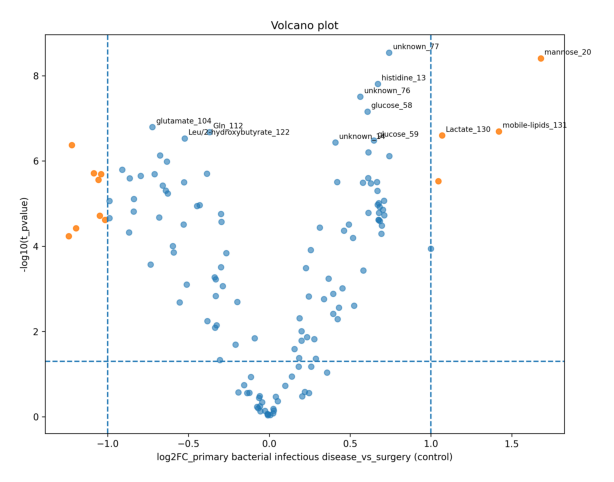

In [6]:

# Volcano plot
volcano = plot_volcano(
    uni,
    list(pd.unique(groups)),
    str(output_dir / "volcano.png"),
    preferred,
    p_threshold,
    fc_threshold,
    top_n_labels,
)
volcano.to_csv(output_dir / "volcano_plot_data.csv", index=False)

plt.figure(figsize=(8, 6))
img = plt.imread(output_dir / "volcano.png")
plt.imshow(img)
plt.axis("off")
plt.show()


In [7]:

# PCA
if pca_components < 2:
    raise ValueError("pca_components must be at least 2.")

pca = run_pca(
    X_scaled,
    groups,
    str(output_dir),
    pca_components,
    show_names=show_sample_names,
    show_ellipse=not no_hotelling,
)

pca["scores"].to_csv(output_dir / "pca_scores.csv")
pca["loadings"].to_csv(output_dir / "pca_loadings.csv")
pca["explained_variance"].to_csv(output_dir / "pca_explained_variance.csv", index=False)

pca_biplot_rank = plot_pca_biplot(
    pca,
    groups,
    str(output_dir / "pca_biplot.png"),
    top_n_labels,
)
pca_biplot_rank.to_csv(output_dir / "pca_biplot_loadings_ranked.csv", index=False)

pca["explained_variance"]


,component,explained_variance_ratio,explained_variance_percent
0,PC1,0.606105,60.610497
1,PC2,0.073954,7.395369
2,PC3,0.044172,4.417180
3,PC4,0.036370,3.636992
4,PC5,0.028179,2.817948


In [8]:

# OPLS-DA
if cv_folds < 2:
    raise ValueError("cv_folds must be at least 2.")

opls = fit_opls(X_scaled, groups, opls_components, cv_folds, permutations)

yb, mapping = encode_groups(groups)
opls_scores = pd.DataFrame({"group": groups.values, "t_pred": opls.scores_pred.values}, index=X_scaled.index)
if opls.scores_orth.shape[1]:
    opls_scores = pd.concat([opls_scores, opls.scores_orth], axis=1)

opls_scores.to_csv(output_dir / "oplsda_scores.csv")
pd.concat([
    opls.loadings_pred,
    opls.weights_pred,
    opls.coef,
    opls.covariance,
    opls.correlation,
    opls.vip,
], axis=1).to_csv(output_dir / "oplsda_feature_statistics.csv")
pd.DataFrame({
    "sample": X_scaled.index,
    "group": groups.values,
    "y_binary": yb,
    "y_pred_cv": opls.y_pred_cv,
}).to_csv(output_dir / "oplsda_cv_predictions.csv", index=False)
pd.DataFrame({
    "metric": ["Q2", "accuracy", "AUC"],
    "value": [opls.q2, opls.accuracy, opls.auc],
}).to_csv(output_dir / "oplsda_summary.csv", index=False)
opls.permutation_q2.to_csv(output_dir / "oplsda_permutation_q2.csv", index=False)

print("Group encoding:", mapping)
pd.DataFrame({"metric": ["Q2", "accuracy", "AUC"], "value": [opls.q2, opls.accuracy, opls.auc]})


Group encoding: {0: 'surgery (control)', 1: 'primary bacterial infectious disease'}


,metric,value
0,Q2,0.478797
1,accuracy,0.886076
2,AUC,0.930370


In [9]:

# OPLS-DA plots
plot_opls_scores(opls, groups, str(output_dir / "oplsda_scores.png"), show_names=show_sample_names, show_ellipse=not no_hotelling)
plot_vip(opls.vip, str(output_dir / "oplsda_vip.png"), min(30, X_scaled.shape[1]))
plot_perm(opls.permutation_q2, opls.q2, str(output_dir / "oplsda_permutation_q2.png"))
s_df = plot_splot(opls, str(output_dir / "oplsda_splot.png"), top_n_labels)
s_df.to_csv(output_dir / "oplsda_splot_data.csv", index=False)

s_df.head(10)


,metabolite,covariance,correlation,VIP,abs_covariance,abs_correlation
0,mannose_20,3.659510,0.790305,1.989480,3.659510,0.790305
1,mobile-lipids_131,3.306546,0.804128,1.812130,3.306546,0.804128
2,glucarate_25,-3.193933,-0.766906,1.769995,3.193933,0.766906
3,Lactate_130,3.026011,0.775270,1.644094,3.026011,0.775270
4,unknown_5,-2.816663,-0.877718,1.635140,2.816663,0.877718
5,unknown_121,-2.837293,-0.944875,1.613054,2.837293,0.944875
6,Arg_120,-2.805936,-0.930659,1.610467,2.805936,0.930659
7,unknown_128,-2.867590,-0.885919,1.599730,2.867590,0.885919
8,unknown_105,-2.733523,-0.893297,1.593705,2.733523,0.893297
9,unknown_117,-2.888461,-0.878375,1.576973,2.888461,0.878375


In [10]:

# Boxplots and heatmaps
top_mets = uni.sort_values(rank_col)["metabolite"].head(top_n_boxplots).tolist()
boxplots = plot_boxplots(X_log, groups, top_mets, str(box_dir))

met_corr = clustered_correlation_heatmap(
    X_log,
    str(output_dir / "metabolite_correlation_heatmap.png"),
    axis="metabolites",
    method=corr_method,
)
met_corr.to_csv(output_dir / "metabolite_correlation_matrix_clustered.csv")

sample_corr = clustered_correlation_heatmap(
    X_log,
    str(output_dir / "sample_correlation_heatmap.png"),
    axis="samples",
    method=corr_method,
)
sample_corr.to_csv(output_dir / "sample_correlation_matrix_clustered.csv")

abundance_heatmap = clustered_abundance_heatmap(
    X_log,
    str(output_dir / "metabolite_sample_heatmap.png"),
    row_axis="metabolites",
    col_axis="samples",
)
abundance_heatmap.to_csv(output_dir / "metabolite_sample_matrix_clustered.csv")

print(f"Saved {len(boxplots)} boxplots")


Saved 12 boxplots


In [11]:

# Optional nested cross-validation
nested_summary = None
nested_folds = None
nested_pred = None

if outer_cv_folds and outer_cv_folds > 1:
    nested_folds, nested_summary, nested_pred = nested_opls_cv(
        X_raw,
        groups,
        normalization,
        log_transform,
        scaling,
        opls_components,
        cv_folds,
        outer_cv_folds,
    )
    nested_folds.to_csv(output_dir / "nested_opls_cv_folds.csv", index=False)
    nested_summary.to_csv(output_dir / "nested_opls_cv_summary.csv", index=False)
    nested_pred.to_csv(output_dir / "nested_opls_cv_predictions.csv", index=False)
    display(nested_summary)
else:
    print("Nested CV skipped. Set outer_cv_folds > 1 to run it.")


Nested CV skipped. Set outer_cv_folds > 1 to run it.


In [12]:

# Build PDF report and save metadata
meta = {
    "input_file": input_file,
    "sample_col": resolved_sample_col,
    "group_col": resolved_group_col,
    "normalization": normalization,
    "log_transform": log_transform,
    "scaling": scaling,
    "n_samples": int(X_scaled.shape[0]),
    "n_metabolites": int(X_scaled.shape[1]),
    "groups": list(pd.unique(groups)),
    "univariate": univariate_method,
    "pca_components": pca_components,
    "opls_components": opls_components,
    "cv_folds": cv_folds,
    "outer_cv_folds": outer_cv_folds,
    "permutations": permutations,
    "top_n_labels": top_n_labels,
    "top_n_boxplots": top_n_boxplots,
    "p_threshold": p_threshold,
    "fc_threshold": fc_threshold,
    "corr_method": corr_method,
}

with open(output_dir / "run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

figs = {
    "volcano": str(output_dir / "volcano.png"),
    "pca_scores": str(output_dir / "pca_scores.png"),
    "pca_biplot": str(output_dir / "pca_biplot.png"),
    "opls_scores": str(output_dir / "oplsda_scores.png"),
    "opls_splot": str(output_dir / "oplsda_splot.png"),
    "opls_vip": str(output_dir / "oplsda_vip.png"),
    "opls_perm": str(output_dir / "oplsda_permutation_q2.png"),
    "met_corr": str(output_dir / "metabolite_correlation_heatmap.png"),
    "sample_corr": str(output_dir / "sample_correlation_heatmap.png"),
    "abundance_heatmap": str(output_dir / "metabolite_sample_heatmap.png"),
}

build_report(
    str(output_dir / "metabolomics_report.pdf"),
    meta,
    uni,
    preferred,
    pca,
    opls,
    figs,
    boxplots,
    s_df,
    nested_summary,
)

print("Done.")
print("PDF report:", output_dir / "metabolomics_report.pdf")


Done.
PDF report: results/metabolomics_report.pdf
